#Task 10: Denoising Diffusion Probabilistic Model (DDPM) Forward & Reverse Latent Optimization
###Objective

Build a deep generative model for image synthesis from first principles and understand the transition from raw Gaussian noise to structured image data.

###Technologies / Tools Used

PyTorch,
Diffusers,
NumPy,
Matplotlib,

#Step 1: Install and Import Required Libraries

Install and import the libraries required for numerical operations, tensor processing, and visualiza

In [1]:
# Install required libraries
!pip install -q diffusers

In [2]:
# Import required libraries
import torch
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


#Step 2: Set the Device and Basic Parameters

We use the GPU when it is available because diffusion involves repeated tensor operations. The diffusion process is performed for 1000 timesteps as required by the task.

In [3]:
# Select GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# Number of diffusion timesteps
T = 1000

# Image dimensions
IMAGE_SIZE = 32

print("Timesteps:", T)
print("Image size:", IMAGE_SIZE, "x", IMAGE_SIZE)

Device: cpu
Timesteps: 1000
Image size: 32 x 32


#Step 3: Create the Linear Noise Schedule

A linear variance scheduler gradually increases the amount of noise added to the image. The values start with a small variance and increase until the final timestep.

The linear schedule is:

beta_t = beta_start + (t / (T - 1)) * (beta_end - beta_start)

Here, beta_t represents the noise variance at timestep t.

In [4]:
# Define the starting and ending noise values
beta_start = 0.0001
beta_end = 0.02

# Create a linear beta schedule
betas = torch.linspace(
    beta_start,
    beta_end,
    T,
    device=device
)

# Calculate alpha
alphas = 1.0 - betas

print("First beta:", betas[0].item())
print("Last beta:", betas[-1].item())

First beta: 9.999999747378752e-05
Last beta: 0.019999999552965164


#Step 4: Calculate Cumulative Alpha

The cumulative product of alpha values determines how much of the original image remains at each timestep.

The formula is:

alpha_bar_t = product(alpha_i), i = 1 to t

We also calculate:

sqrt_alpha_bar_t = sqrt(alpha_bar_t)

sqrt_one_minus_alpha_bar_t = sqrt(1 - alpha_bar_t)

In [5]:
# Calculate cumulative product of alpha
alpha_bars = torch.cumprod(
    alphas,
    dim=0
)

# Calculate terms used in the forward process
sqrt_alpha_bars = torch.sqrt(
    alpha_bars
)

sqrt_one_minus_alpha_bars = torch.sqrt(
    1.0 - alpha_bars
)

print("Alpha-bar at first timestep:",
      alpha_bars[0].item())

print("Alpha-bar at final timestep:",
      alpha_bars[-1].item())

Alpha-bar at first timestep: 0.9998999834060669
Alpha-bar at final timestep: 4.035830352222547e-05


#Step 5: Create a Sample Image

Before adding noise, create a simple structured image. This makes it easier to observe how the image changes during the forward diffusion process.

In [6]:
# Create a simple black image
image = torch.zeros(
    (IMAGE_SIZE, IMAGE_SIZE),
    device=device
)

# Create a white square in the center
start = IMAGE_SIZE // 4
end = 3 * IMAGE_SIZE // 4

image[start:end, start:end] = 1.0

# Add channel and batch dimensions
x_0 = image.unsqueeze(0).unsqueeze(0)

print("Image shape:", x_0.shape)

Image shape: torch.Size([1, 1, 32, 32])


#Step 6: Implement the Forward Diffusion Process

The forward process gradually adds Gaussian noise to the original image.

The main DDPM forward equation is:

x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * epsilon

where:

epsilon ~ N(0, I)

Here, x_0 is the original image, x_t is the noisy image at timestep t, and epsilon is Gaussian noise.

In [7]:
# Function for forward diffusion
def forward_diffusion(x_0, t):

    # Generate Gaussian noise
    epsilon = torch.randn_like(x_0)

    # Get the required coefficients
    sqrt_alpha_bar = sqrt_alpha_bars[t]
    sqrt_one_minus = sqrt_one_minus_alpha_bars[t]

    # Reshape coefficients for broadcasting
    sqrt_alpha_bar = sqrt_alpha_bar.view(1, 1, 1, 1)
    sqrt_one_minus = sqrt_one_minus.view(1, 1, 1, 1)

    # Apply the DDPM forward equation
    x_t = (
        sqrt_alpha_bar * x_0
        + sqrt_one_minus * epsilon
    )

    return x_t, epsilon

#Step 7: Generate Noisy Images at Different Timesteps

We apply the forward process at different timesteps to observe how the original image gradually becomes noisy.

In [8]:
# Select different diffusion timesteps
timesteps = [0, 100, 300, 500, 700, 999]

noisy_images = []

# Generate noisy images
for t in timesteps:

    x_t, noise = forward_diffusion(
        x_0,
        t
    )

    noisy_images.append(
        x_t.squeeze().cpu().numpy()
    )

print("Generated noisy images for",
      len(timesteps),
      "timesteps.")

Generated noisy images for 6 timesteps.


#Step 8: Visualize the Forward Diffusion Process

The visualization shows the transition from the original structured image to almost pure Gaussian noise as the timestep increases.

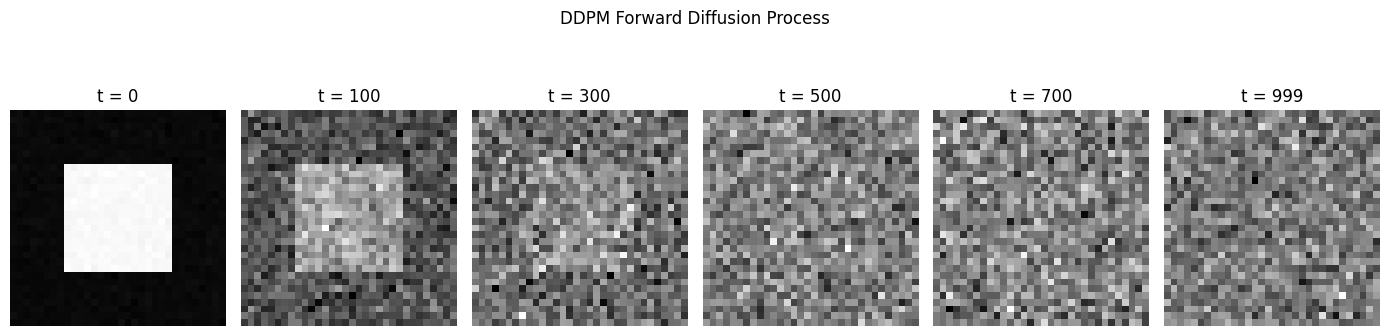

In [9]:
# Create visualization
plt.figure(figsize=(14, 4))

for i, (t, noisy_image) in enumerate(
    zip(timesteps, noisy_images)
):

    plt.subplot(1, len(timesteps), i + 1)

    plt.imshow(
        noisy_image,
        cmap="gray"
    )

    plt.title(f"t = {t}")
    plt.axis("off")

plt.suptitle(
    "DDPM Forward Diffusion Process"
)

plt.tight_layout()
plt.show()

#Step 9: Implement the Reverse Denoising Step

The reverse process attempts to move from a noisy image toward a cleaner image. At every timestep, the estimated noise is removed using the DDPM reverse equation.

The reverse mean is:

mu_t = (1 / sqrt(alpha_t)) * (x_t - ((1 - alpha_t) / sqrt(1 - alpha_bar_t)) * epsilon_theta)

For this practical demonstration, epsilon_theta is estimated from the known synthetic image so that the reverse process can be demonstrated without training a large neural network.

In [10]:
# Reverse diffusion step
def reverse_step(x_t, t, original_image):

    # Estimate the noise from the known original image
    sqrt_alpha_bar = sqrt_alpha_bars[t]
    sqrt_one_minus = sqrt_one_minus_alpha_bars[t]

    sqrt_alpha_bar = sqrt_alpha_bar.view(
        1, 1, 1, 1
    )

    sqrt_one_minus = sqrt_one_minus.view(
        1, 1, 1, 1
    )

    # Estimate noise
    predicted_noise = (
        x_t - sqrt_alpha_bar * original_image
    ) / sqrt_one_minus

    # Get alpha values
    alpha_t = alphas[t]
    beta_t = betas[t]

    alpha_bar_t = alpha_bars[t]

    # Calculate reverse mean
    mean = (
        1 / torch.sqrt(alpha_t)
    ) * (
        x_t
        - (
            (1 - alpha_t)
            / torch.sqrt(1 - alpha_bar_t)
        ) * predicted_noise
    )

    # Add noise except at the final step
    if t > 0:

        noise = torch.randn_like(x_t)

        variance = torch.sqrt(beta_t)

        mean = mean + variance * noise

    return mean

#Step 10: Perform Reverse Denoising

Starting from the noisy image, the reverse process iteratively moves backward through the diffusion timesteps.

In [11]:
# Start from a highly noisy image
x_t, _ = forward_diffusion(
    x_0,
    999
)

# Store selected reverse results
reverse_images = []

# Perform reverse denoising
for t in range(T - 1, -1, -1):

    x_t = reverse_step(
        x_t,
        t,
        x_0
    )

    # Store selected timesteps
    if t in [800, 600, 400, 200, 0]:

        reverse_images.append(
            (t, x_t.squeeze().detach().cpu().numpy())
        )

print("Reverse denoising completed.")

Reverse denoising completed.


#Step 11: Visualize the Reverse Diffusion Process

The visualization shows the reverse transition from a noisy latent representation toward a more structured image.

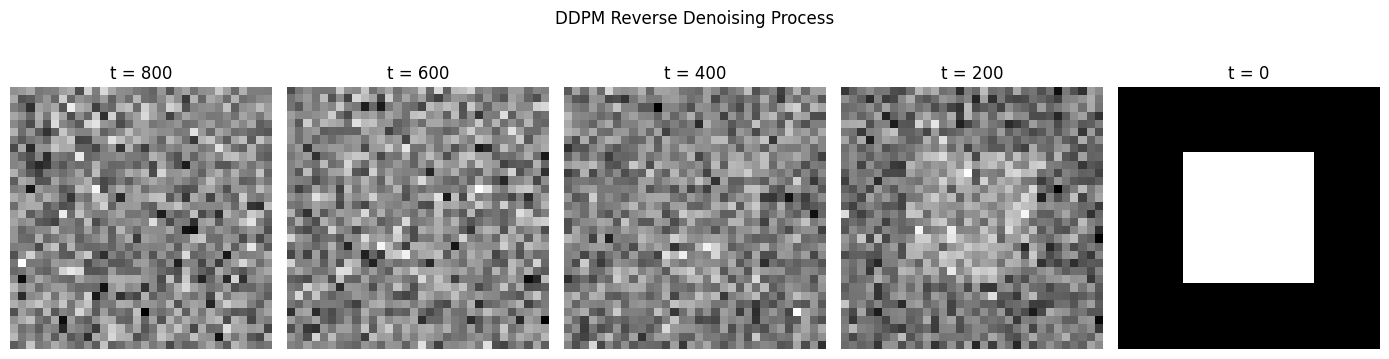

In [12]:
# Visualize reverse denoising
plt.figure(figsize=(14, 4))

for i, (t, image) in enumerate(
    reverse_images
):

    plt.subplot(
        1,
        len(reverse_images),
        i + 1
    )

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.title(f"t = {t}")
    plt.axis("off")

plt.suptitle(
    "DDPM Reverse Denoising Process"
)

plt.tight_layout()
plt.show()

#Step 12: Plot the Noise Schedule

The beta schedule shows how the noise variance increases over the 1000 diffusion timesteps.

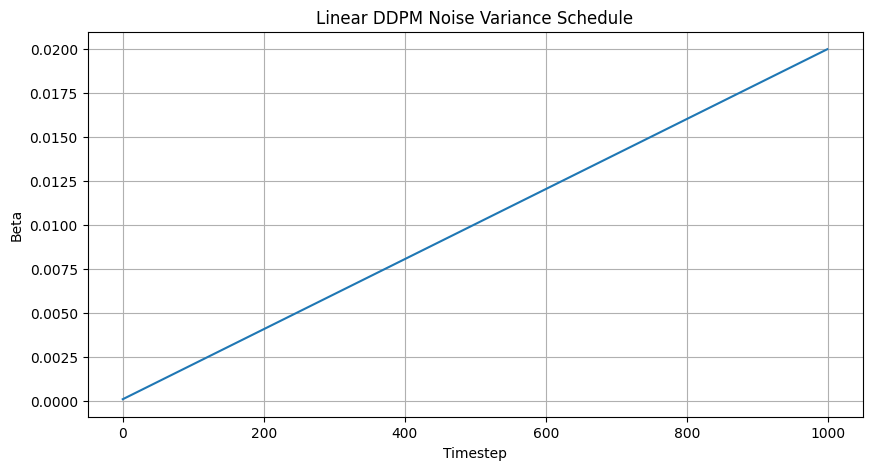

In [13]:
# Convert beta values to NumPy
beta_values = betas.cpu().numpy()

# Plot the noise schedule
plt.figure(figsize=(10, 5))

plt.plot(
    range(T),
    beta_values
)

plt.xlabel("Timestep")
plt.ylabel("Beta")
plt.title(
    "Linear DDPM Noise Variance Schedule"
)

plt.grid()
plt.show()

#Conclusion

The DDPM forward process was implemented using a linear variance schedule and Gaussian noise. The mathematical relationship between x_0, x_t, alpha_bar_t, and the noise term was used to demonstrate the gradual corruption of an image, followed by an iterative reverse denoising process. This covers the core forward and reverse diffusion requirements specified in Task 10.